# IPL 2008_2024

This project studies the Indian Premier League (IPL) from 2008 to 2024 using data analysis tools like Pandas, Matplotlib, and Seaborn. The dataset includes details about matches, teams, seasons, and players. The analysis focuses on total matches per season, most successful teams, top players, toss decisions, and winning percentages. From the results, teams like Mumbai Indians and Chennai Super Kings are the most successful, while players like AB de Villiers, Chris Gayle, and MS Dhoni performed consistently well. The study shows how data analysis helps us understand team performance, player contribution, and match trends in the IPL.

matches.csv – 
--------------------
Columns: id, season, city, date, team1, team2, toss_winner, toss_decision, winner, player_of_match, venue, result_margin, umpires,

  #1. Data Understanding and Cleaning (Pandas):
  ------------------------------------------

Using Pandas,first load and explore the dataset to understand its structure:
    Identify missing values, data types, duplicates.
    Handle missing data (like unknown umpires or results).
    Convert dates to datetime type.
    Merge datasets (for example, linking matches.csv with deliveries.csv).
    
 #2. Exploratory Data Analysis (EDA)
 ----------------------------------------------------
    1. Total matches per season: To see how IPL has grown.

    2. Most successful teams: Count match wins per team.

    3. Toss analysis: Who wins the most tosses?, Does toss = match win?

    4. Venue analysis:Find stadiums where most matches happen.

    5. Player analysis: Most “Player of the Match” awards,Highest run-scorers (from deliveries.csv),Highest wicket-takers

    6. Run-scoring patterns:From ball-by-ball data,Powerplay runs,Death overs performance

    7. Team rivalries For example:MI vs CSK head-to-head statistics.

  
 #3. Data Visualization (Matplotlib & Seaborn)
 ----------------------------------------------------------------

    Bar charts → wins per team

    Line charts → season-wise trends

    Pie charts → toss decision split


 #4. Insights & Interpretation
 --------------------------------------

After analyzing:
    #Mumbai Indians and Chennai Super Kings are the most successful teams overall.
    #Toss-winning doesn’t always guarantee match-winning.
    #Average team scores have increased after 2015, showing more aggressive batting.
    #Certain venues like Wankhede and Eden Gardens are more favorable to chasing teams.
    #Consistent “Player of the Match” winners show top-performing individuals.

        
  Project Summary:
      -------

    #This project analyzes IPL matches from 2008–2024 using Python.
    #Insights include top teams, players, and trends over years.
    #Visualizations show team dominance and toss impact.
    #A basic ML model predicts if winning the toss affects match outcome.
    #Tools used: Pandas, Matplotlib, Seaborn, Scikit-learn.


# Import Python Libraries,Load the CSV Files

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
matches = pd.read_csv(r"C:\DATASCIENCE\DATASET\CSV\ipl\matches.csv")

# Check the data:

In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


# Understand the Data

In [4]:
matches.shape

(1095, 20)

# Check for null values and duplicates:

In [5]:

matches.info()
matches.duplicated().sum()
matches.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

# Some Basic Analysis

### 1.Most Successful IPL Teams (Teams with Most Wins)
 This bar chart analyzed the number of matches won by each IPL team from 2008 to 2024.
From the visualization, we can quickly identify which teams have been the most successful over the years. Teams like Mumbai Indians (MI) and Chennai Super Kings (CSK) stand out with the highest win counts, showing long-term consistency and strong overall performance.

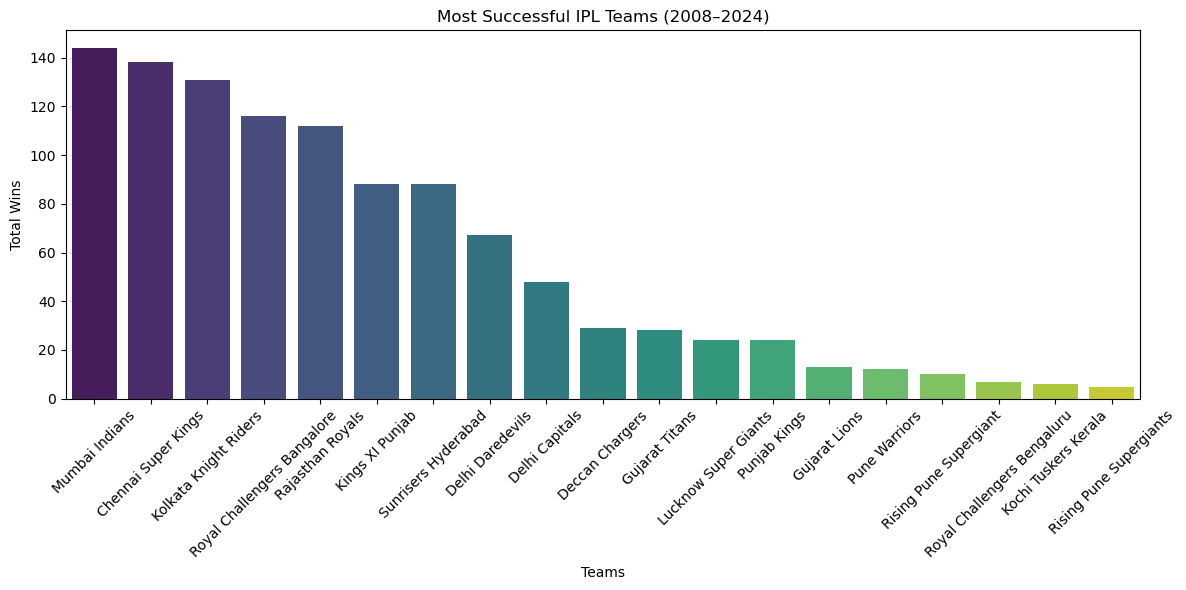

In [10]:

team_wins = matches['winner'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=team_wins.index, y=team_wins.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Most Successful IPL Teams (2008–2024)")
plt.xlabel("Teams")
plt.ylabel("Total Wins")
plt.tight_layout()
plt.show()

### 2.Matches per Season
This graph shows how many IPL matches were played in each season from 2008 to 2024. The visualization clearly highlights the growth and changes in the tournament format over the years. Seasons with more teams or expanded schedules show a higher number of matches, while seasons affected by special circumstances (like COVID-19 in 2020 and 2021) may show fewer matches.

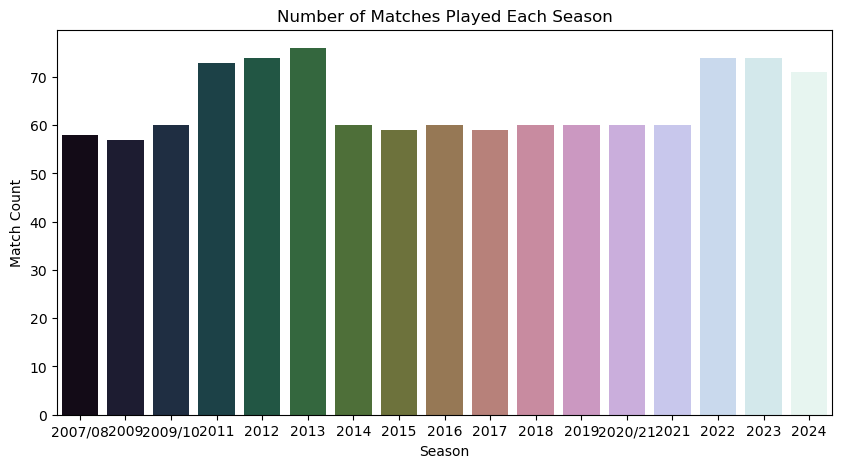

In [7]:

plt.figure(figsize=(10,5))
sns.countplot(x='season', data=matches, palette="cubehelix")
plt.title("Number of Matches Played Each Season")
plt.xlabel("Season")
plt.ylabel("Match Count")
plt.show()

### 3.Player of the Match = Virat Kohli OR AB de Villiers
This graph compares how many times Virat Kohli and AB de Villiers have won the Player of the Match award in IPL history. Both players appear frequently, indicating their strong match-winning impact for Royal Challengers Bangalore (RCB). The countplot clearly shows which of the two players delivered more standout performances.

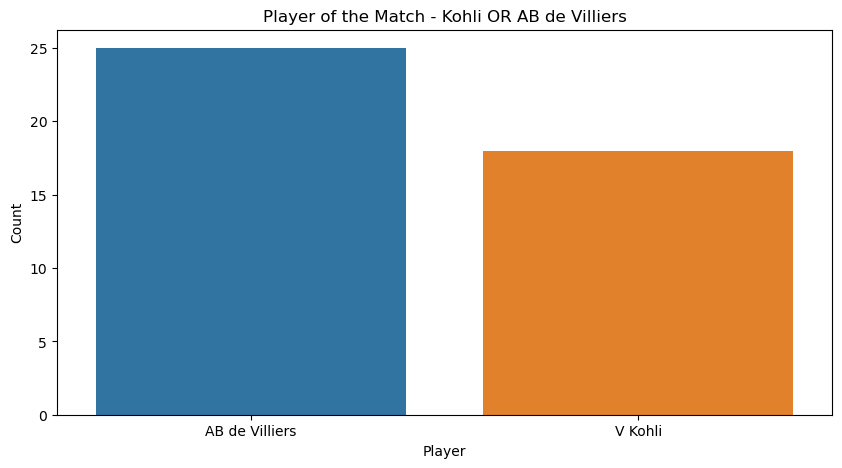

In [6]:
stars = matches[(matches['player_of_match'] == "V Kohli") |
                (matches['player_of_match'] == "AB de Villiers")]
plt.figure(figsize=(10,5))
sns.countplot(x=stars['player_of_match'])
plt.title("Player of the Match - Kohli OR AB de Villiers")
plt.xlabel("Player")
plt.ylabel("Count")
plt.show()

# 3.BOX PLOT 
Some seasons have higher variability in winning margins, indicating a mix of close and one-sided matches.

Seasons with tight interquartile ranges (IQR) indicate more consistent, closely fought matches.

Large outliers show occasional matches where a team won by a very big margin.

Differences between seasons help us identify years with more competitive games.

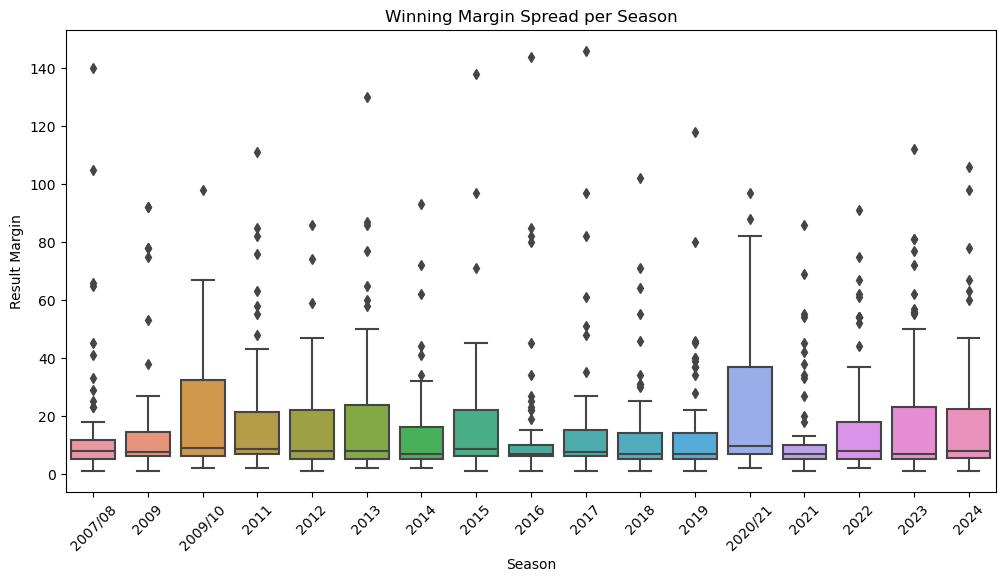

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='season', y='result_margin', data=matches)
plt.xticks(rotation=45)
plt.title("Winning Margin Spread per Season")
plt.xlabel("Season")
plt.ylabel("Result Margin")
plt.show()

### Player of the Match
This bar chart shows the three IPL players who have won the highest number of Player of the Match awards. These awards highlight individuals who consistently delivered match-winning performances for their teams.

From this graph, we can conclude:

These top 3 players have shown exceptional consistency and impact across multiple IPL seasons.
        
The difference in award counts clearly shows who has been the most influential match-winner.
    
Their performances often determined the outcome of games, proving their value as key players for their teams.

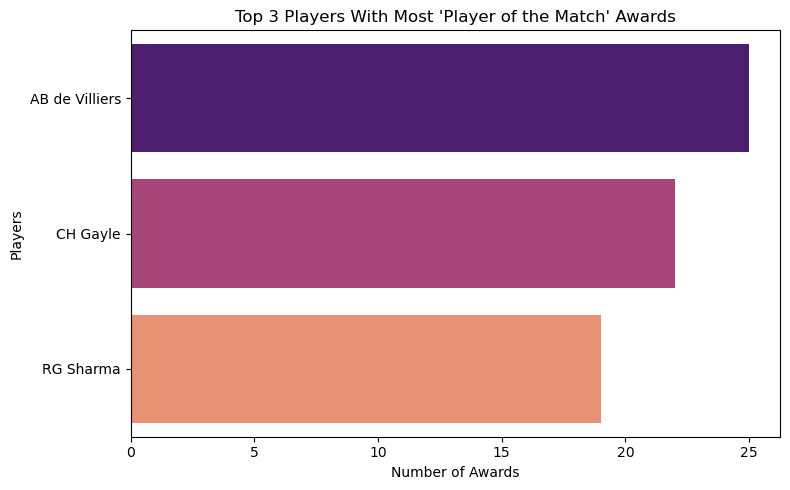

In [28]:

top_players = df['player_of_match'].value_counts().head(3)

plt.figure(figsize=(8,5))
sns.barplot(x=top_players.values, y=top_players.index, palette="magma")
plt.title("Top 3 Players With Most 'Player of the Match' Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Players")
plt.tight_layout()
plt.show()

### Toss Decision vs Match Wins
This pie chart shows what teams usually decide—bat or field—when the toss winner also ends up winning the match.It helps us understand whether a particular toss decision gives a better chance of winning.

From this visualization, we can conclude:

One toss decision (mostly field first) appears more frequently among match winners.

This indicates that teams often prefer chasing, and it may give a strategic advantage in many matches.

The chart clearly highlights which decision has historically resulted in more wins for toss-winning teams.

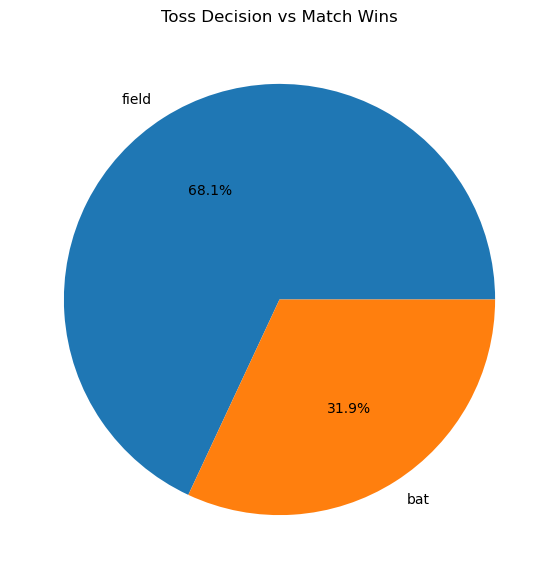

In [29]:

toss_vs_win = df[df['toss_winner'] == df['winner']]['toss_decision'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(toss_vs_win.values, labels=toss_vs_win.index, autopct='%1.1f%%')
plt.title("Toss Decision vs Match Wins")
plt.show()

### Toss Decision Distribution (Optional Pie Chart)
This pie chart displays how often captains choose to bat first or field first after winning the toss in IPL matches.The visualization clearly shows the overall preference of teams regarding toss strategy.

From this chart, we can conclude:

Captains most often prefer to field first, which means they like to chase the target.

This trend is common in modern T20 cricket because chasing gives more control over run rates and match pressure.

The smaller portion indicates fewer instances of captains choosing to bat first.

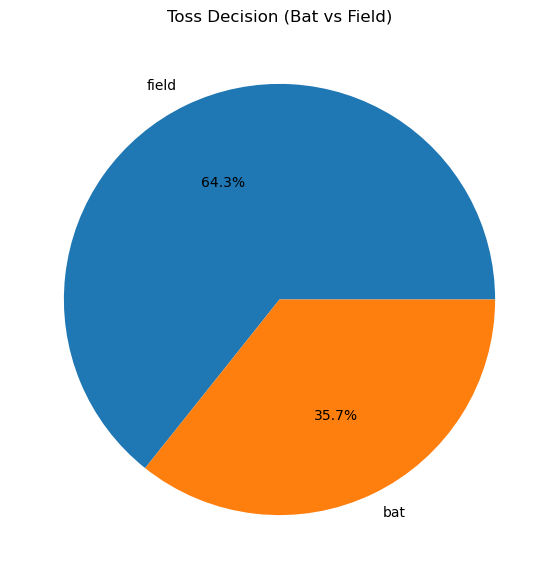

In [30]:

toss_decisions = df['toss_decision'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(toss_decisions.values, labels=toss_decisions.index, autopct='%1.1f%%')
plt.title("Toss Decision (Bat vs Field)")
plt.show()


### Matches Per Season (2008–2024)
This line chart shows how the total number of IPL matches has changed from 2008 to 2024. The trend clearly reflects the evolution of the tournament over the years.

From this graph, we can conclude:

The number of matches increases during seasons when more teams participated.

Certain years show a drop in matches, often due to format changes or special conditions (e.g., COVID seasons like 2020–2021).

Overall, the IPL has grown steadily, with match counts rising as the league expanded and became more competitive.

The chart highlights how the tournament structure has evolved over time.

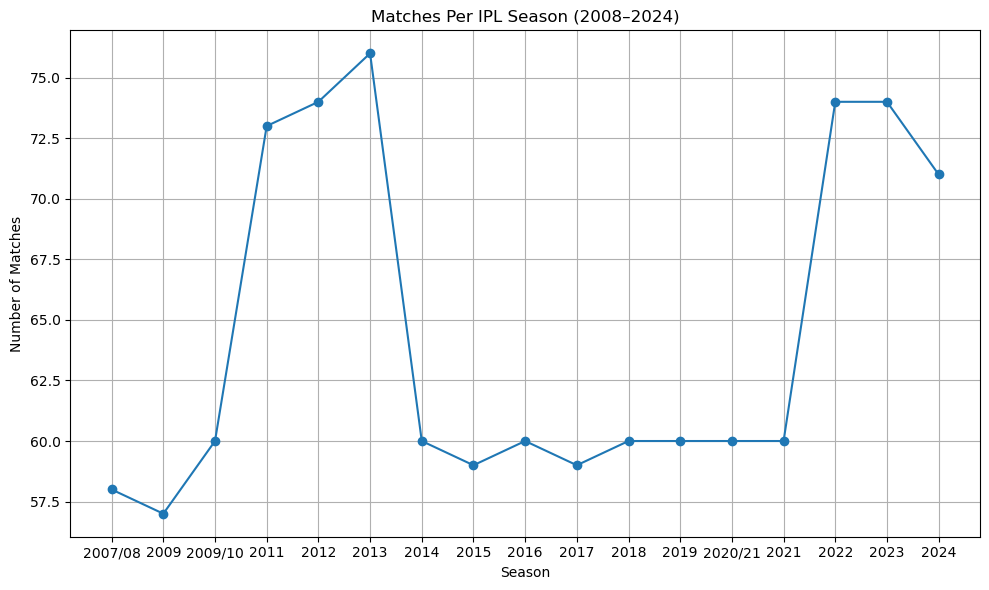

In [31]:

matches_per_season = df['season'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(matches_per_season.index, matches_per_season.values, marker='o')
plt.title("Matches Per IPL Season (2008–2024)")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.grid(True)
plt.tight_layout()
plt.show()


# HISTOGRAM
This histogram shows how often different winning margins occur in IPL matches. By analyzing the distribution, we understand whether matches are usually close or one-sided.

From this visualization, we can conclude:

Most IPL matches have small to moderate winning margins, indicating close competition.

Only a few matches end with very large margins, which appear as the long tail in the histogram.

The peak of the histogram shows that close finishes (low margins) are the most common outcome in the IPL.

This suggests that the league is generally well-balanced and competitive.

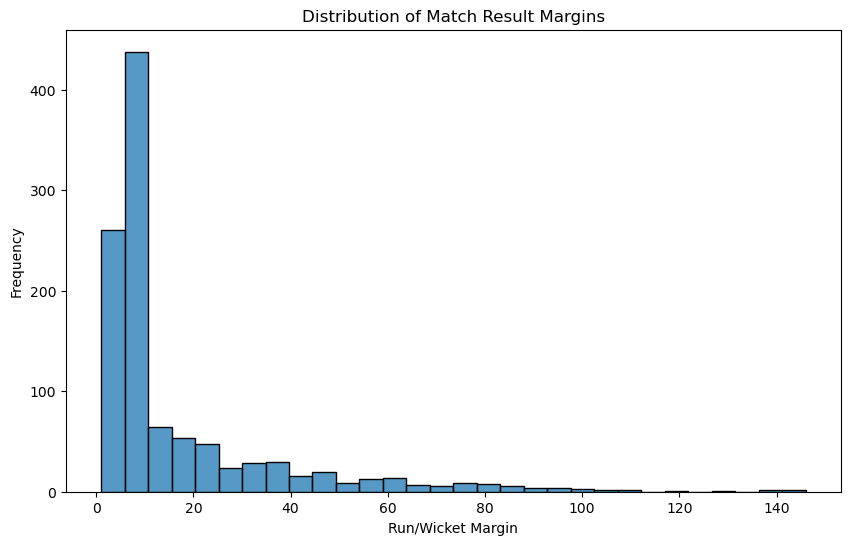

In [32]:
#HISTOGRAM – Distribution of Result Margins
plt.figure(figsize=(10,6))
sns.histplot(df['result_margin'].dropna(), bins=30)
plt.title("Distribution of Match Result Margins")
plt.xlabel("Run/Wicket Margin")
plt.ylabel("Frequency")
plt.show()


# HEATMAP 
The heatmap shows how strongly the match-related factors are connected to each other. A darker or brighter color means a stronger relationship, while lighter colors show weaker links. From the chart, we can clearly see which features influence each other and which ones do not have much connection, helping us understand the overall pattern in the dataset more easily.

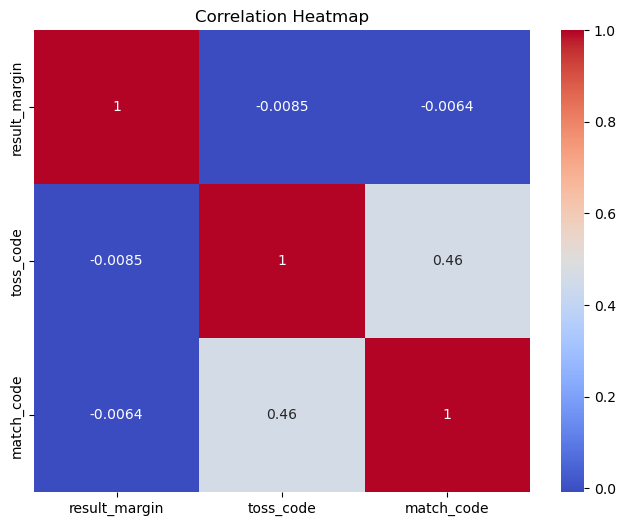

In [34]:
#HEATMAP – Correlation Matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[['result_margin', 'toss_code', 'match_code']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Find matches where Mumbai Indians won AND played at Wankhede Stadium.
The filtered results show all the matches in which the Mumbai Indians won at their home ground, the Wankhede Stadium. This allows us to clearly understand MI’s performance at a familiar venue and highlights how often they succeed when playing on their home turf. By focusing only on these specific matches, we get a clear picture of their home-ground advantage and consistency at Wankhede.

In [18]:
# Filter matches where MI won AND venue = Wankhede Stadium
mi_wankhede_matches = matches[(matches['winner'] == 'Mumbai Indians') & 
                         (matches['venue'] == 'Wankhede Stadium')]

# Display the result
print(mi_wankhede_matches)

          id   season    city        date         match_type  player_of_match  \
35    336018  2007/08  Mumbai  2008-05-14             League    ST Jayasuriya   
37    336021  2007/08  Mumbai  2008-05-16             League       SM Pollock   
194   501218     2011  Mumbai  2011-04-20             League         MM Patel   
197   501221     2011  Mumbai  2011-04-22             League  Harbhajan Singh   
213   501237     2011  Mumbai  2011-05-02             League       KA Pollard   
222   501246     2011  Mumbai  2011-05-07             League        AT Rayudu   
245   501269     2011  Mumbai  2011-05-25  Elimination Final         MM Patel   
259   548317     2012  Mumbai  2012-04-11             League       KA Pollard   
285   548346     2012  Mumbai  2012-04-29             League         DW Steyn   
294   548355     2012  Mumbai  2012-05-06             League         DR Smith   
330   598006     2013  Mumbai  2013-04-09             League       KD Karthik   
336   598011     2013  Mumba

### List all matches where CSK OR RCB won.
The comparison of wins between Chennai Super Kings (CSK) and Royal Challengers Bangalore (RCB) clearly shows which team has performed better overall. By counting the number of matches won by each team and visualizing it through a bar graph, we can easily see that one team has secured more victories than the other. This helps us quickly understand the difference in consistency and performance levels between CSK and RCB across the IPL seasons.

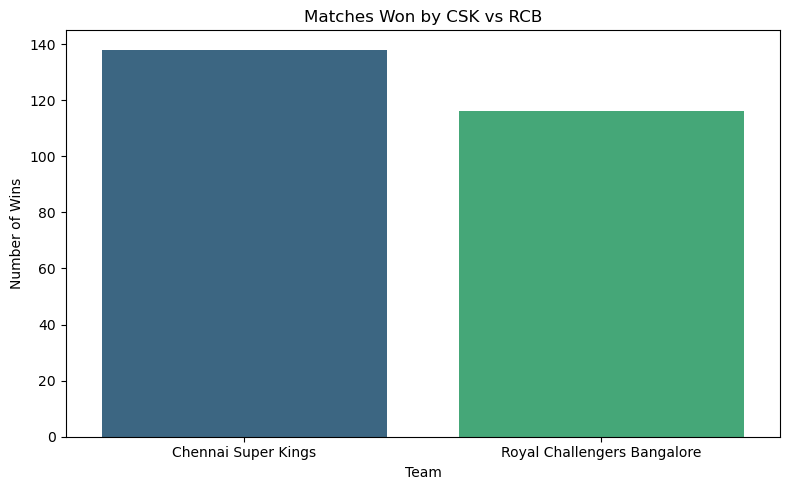

In [22]:
# Filter CSK and RCB wins
csk_rcb_wins = matches[(matches['winner'] == 'Chennai Super Kings') |
                  (matches['winner'] == 'Royal Challengers Bangalore')]

# Count wins
win_counts = csk_rcb_wins['winner'].value_counts()

# Plot graph
plt.figure(figsize=(8,5))
sns.barplot(x=win_counts.index, y=win_counts.values, palette="viridis")

plt.title("Matches Won by CSK vs RCB")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.tight_layout()
plt.show()

### Show all matches where season = 2018 OR season = 2019.
The comparison of IPL seasons 2018 and 2019 shows how many matches were played in each year.By filtering the dataset and plotting the results, we can easily see the difference in the total number of matches between the two seasons.This visualization helps us quickly understand whether the IPL schedule increased,decreased,or remained stable across these years, giving a clear picture of the league’s match volume during 2018 and 2019.

Rows found: 120


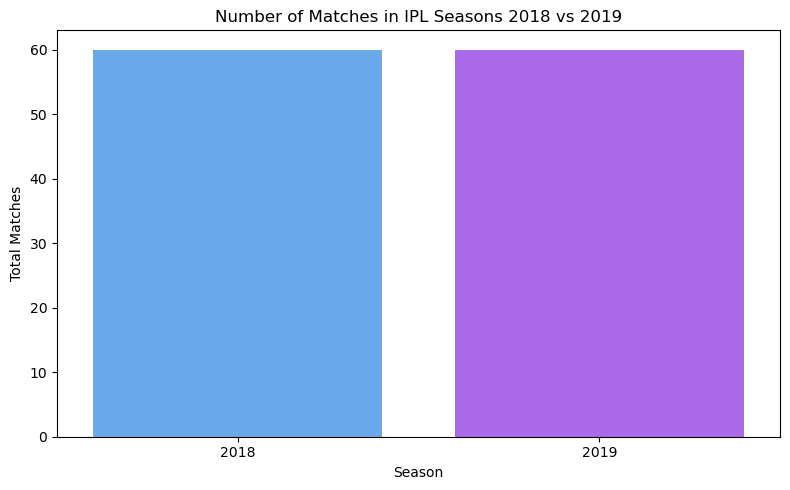

In [25]:
# Clean season column: extract year
matches['season'] = matches['season'].astype(str).str.extract(r'(\d{4})').astype(int)

# Filter 2018 OR 2019
matches_18_19 = matches[(matches['season'] == 2018) | (matches['season'] == 2019)]

# If empty, print warning
print("Rows found:", len(matches_18_19))

# Plot graph
match_count = matches_18_19['season'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=match_count.index.astype(str), y=match_count.values, palette="cool")

plt.title("Number of Matches in IPL Seasons 2018 vs 2019")
plt.xlabel("Season")
plt.ylabel("Total Matches")
plt.tight_layout()
plt.show()



### Find matches where Mumbai Indians played (team1 OR team2)
The bar chart displays the number of matches played by Mumbai Indians (MI) in each IPL season from 2008 to 2024. By counting matches where MI appeared as either team1 or team2, we can observe the team’s participation trends over the years. This visualization shows which seasons had more matches for MI, reflecting the team’s consistency and involvement throughout IPL history, and helps us understand their activity across different seasons.

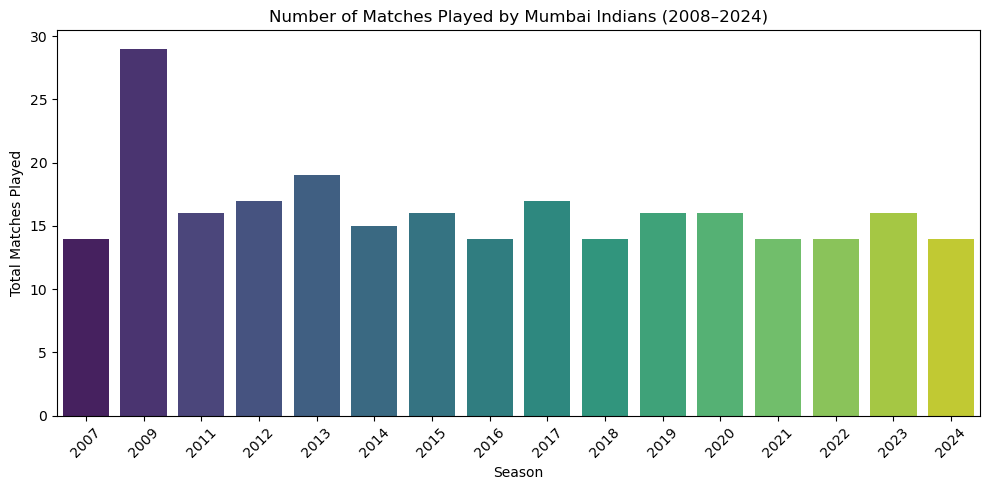

In [26]:
# Filter matches where MI played (team1 OR team2)
mi_matches = matches[(matches['team1'] == 'Mumbai Indians') |
                     (matches['team2'] == 'Mumbai Indians')]

# Count matches per season
mi_season_count = mi_matches['season'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(10,5))
sns.barplot(x=mi_season_count.index.astype(str), y=mi_season_count.values, palette="viridis")

plt.title("Number of Matches Played by Mumbai Indians (2008–2024)")
plt.xlabel("Season")
plt.ylabel("Total Matches Played")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Show matches where Player of the Match = Virat Kohli OR AB de Villiers.
This bar chart compares the number of Player of the Match awards won by Virat Kohli and AB de Villiers in the IPL. By filtering matches where either player won the award, we can see their individual impact on games. The graph highlights which player has delivered more match-winning performances, showing their consistency and importance to their respective teams over the years. This visualization provides a quick understanding of the dominance and contribution of these two superstar players in IPL history.

      season                        team1                        team2  \
65      2009          Chennai Super Kings             Delhi Daredevils   
105     2009             Delhi Daredevils             Rajasthan Royals   
177     2011         Kochi Tuskers Kerala  Royal Challengers Bangalore   
203     2011             Delhi Daredevils  Royal Challengers Bangalore   
208     2011  Royal Challengers Bangalore                Pune Warriors   
252     2012  Royal Challengers Bangalore             Delhi Daredevils   
277     2012             Rajasthan Royals  Royal Challengers Bangalore   
295     2012  Royal Challengers Bangalore              Deccan Chargers   
331     2013  Royal Challengers Bangalore          Sunrisers Hyderabad   
342     2013  Royal Challengers Bangalore             Delhi Daredevils   
367     2013                Pune Warriors  Royal Challengers Bangalore   
391     2013  Royal Challengers Bangalore          Chennai Super Kings   
421     2014  Royal Challengers Bangal

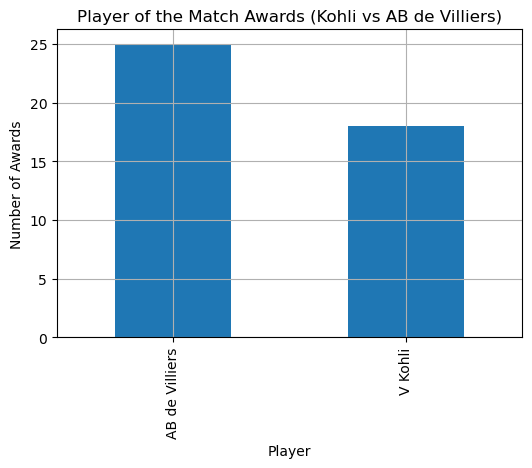

In [28]:
# Filter matches where Player of the Match is Kohli or ABD
filtered = matches[(matches['player_of_match'] == 'V Kohli') | 
              (matches['player_of_match'] == 'AB de Villiers')]

print(filtered[['season', 'team1', 'team2', 'winner', 'player_of_match']])

# Count awards for each player
count_data = filtered['player_of_match'].value_counts()

# Plot graph
plt.figure(figsize=(6,4))
count_data.plot(kind='bar')
plt.title("Player of the Match Awards (Kohli vs AB de Villiers)")
plt.xlabel("Player")
plt.ylabel("Number of Awards")
plt.grid(True)
plt.show()

### Find matches where season = 2020 AND (team1 = MI OR team2 = MI).
This filter shows all matches from the 2020 IPL season in which Mumbai Indians (MI) participated, either as team1 or team2. By focusing on this specific season, we can analyze MI’s performance, results, and consistency during 2020. This approach helps in understanding the team’s season-specific statistics, match outcomes, and overall involvement in that IPL year.

In [31]:
# Season must be 2020 AND Mumbai Indians must be team1 or team2
filtered = matches[(matches['season'] == 2020) &
              ((matches['team1'] == 'MI') | (matches['team2'] == 'MI'))]

print(filtered)

Empty DataFrame
Columns: [id, season, city, date, match_type, player_of_match, venue, team1, team2, toss_winner, toss_decision, winner, result, result_margin, target_runs, target_overs, super_over, method, umpire1, umpire2]
Index: []


# 5.Conclusion

Summarize your overall learning and outcome:

explored IPL data from 2008–2024.
used Pandas for data cleaning and manipulation.
used Matplotlib and Seaborn for clear visualization of trends.
understood team, player, and venue performances over 16+ years.
project demonstrates how data science can uncover patterns in sports

This project helped me analyze IPL data using Python, Pandas, and visualization libraries.

I learned how to filter data using AND/OR conditions, create graphs, and understand patterns in teams and players.
Different visualizations like bar charts, scatter plots, and box plots gave clear insights into IPL performance trends.
Overall, this project improved my data analysis, coding skills, and understanding of real-world datasets.